# Hybrid Lean Vecchia vs Debiased Whittle 2110 — Low-Resolution Diagnostic

Local sanity check (lat ×4, lon ×2) comparing:

| Model | Method | Notes |
|---|---|---|
| `Irr_Baseline_A20_B18_C15` | Vecchia (local-only) | reference |
| `Hybrid_Lean_Fixed_0p063` | Vecchia + fresh hybrid | fixed offset 0.063 |
| `DW_2110` | Debiased Whittle | FFT-based, regular grid |

True advec_lon cycled over `[-0.10, -0.16, -0.25]`.

In [1]:
import io
import contextlib
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC  = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import orderings as _orderings
from GEMS_TCO import debiased_whittle_2110 as dw_module

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float64

DELTA_LAT = 0.044 * 4   # low-res: lat ×4
DELTA_LON = 0.063 * 2   # low-res: lon ×2
T_STEPS   = 8

print("DEVICE:", DEVICE)
print("SRC:",    _src)
print(f"Grid resolution: lat={DELTA_LAT:.3f}, lon={DELTA_LON:.3f}")

DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: lat=0.176, lon=0.126


## Settings

In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 10
SEED = 42

SMOOTH          = 0.5
MM_COND_NUMBER  = 100
NHEADS          = 0
DAILY_STRIDE    = 2

LBFGS_STEPS = 5
LBFGS_EVAL  = 20
LBFGS_HIST  = 10
DWL_STEPS   = 5    # LBFGS steps for Debiased Whittle
INIT_NOISE  = 0.7
SUPPRESS_FIT_PRINTS = True

BASE_TRUE_DICT = {
    "sigmasq":    10.0,
    "range_lat":  0.5,
    "range_lon":  0.6,
    "range_time": 2.5,
    "advec_lat":  0.08,
    "nugget":     1.2,
}
TRUE_ADVEC_LON_LIST    = [-0.10, -0.16, -0.25]
DEFAULT_TRUE_ADVEC_LON = -0.16


def make_true_dict(advec_lon):
    return {**BASE_TRUE_DICT, "advec_lon": float(advec_lon)}


print(f"lon cell = {DELTA_LON:.3f}")
print(f"true advec_lon values: {TRUE_ADVEC_LON_LIST}")

lon cell = 0.126
true advec_lon values: [-0.1, -0.16, -0.25]


## Model Specs

In [3]:
def build_model_specs():
    specs = [
        {
            "name":               "Irr_Baseline_A20_B18_C15",
            "group":              "local_baseline",
            "kernel":             "std",
            "limit_A":            20, "limit_B": 18, "limit_C": 15,
            "lag1_local_count":   18, "lag1_fresh_count": 0,
            "lag2_local_count":   15, "lag2_fresh_count": 0,
            "pred_lag1_lon_offset": 0.0,
            "total_conditioning": 55,
        },
        {
            "name":               "Hybrid_Lean_Fixed_0p063",
            "group":              "hybrid_lean",
            "kernel":             "hybrid_fresh",
            "limit_A":            20, "limit_B": 8, "limit_C": 4,
            "lag1_local_count":   8,  "lag1_fresh_count": 4,
            "lag2_local_count":   4,  "lag2_fresh_count": 3,
            "pred_lag1_lon_offset": 0.063,
            "total_conditioning": 41,
        },
        {
            "name":               "DW_2110",
            "group":              "debiased_whittle",
            "kernel":             "dw",
            "limit_A":            0,  "limit_B": 0, "limit_C": 0,
            "lag1_local_count":   0,  "lag1_fresh_count": 0,
            "lag2_local_count":   0,  "lag2_fresh_count": 0,
            "pred_lag1_lon_offset": 0.0,
            "total_conditioning": 0,   # N/A
        },
    ]
    return {s["name"]: s for s in specs}


MODEL_SPECS = build_model_specs()
spec_df = pd.DataFrame(MODEL_SPECS).T
display(spec_df[[
    "group", "kernel",
    "lag1_local_count", "lag1_fresh_count",
    "lag2_local_count", "lag2_fresh_count",
    "pred_lag1_lon_offset", "total_conditioning",
]])

,group,kernel,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset,total_conditioning
Irr_Baseline_A20_B18_C15,local_baseline,std,18,0,15,0,0.0,55
Hybrid_Lean_Fixed_0p063,hybrid_lean,hybrid_fresh,8,4,4,3,0.063,41
DW_2110,debiased_whittle,dw,0,0,0,0,0.0,0


## Hybrid Fresh Kernel Class (Vecchia)

In [4]:
class fit_vecchia_lbfgs_fresh_hybrid(kernels_vecchia.fit_vecchia_lbfgs):
    """Local lag NN + fresh shifted-center lag NN. Lag-k offset = k × lag1_lon_offset."""

    def __init__(self, smooth, input_map, nns_map, mm_cond_number, nheads,
                 limit_A=20, limit_B=8, limit_C=4, daily_stride=2,
                 spatial_coords=None, lag1_lon_offset=0.063,
                 lag1_fresh_count=4, lag2_fresh_count=3):
        super().__init__(smooth, input_map, nns_map, mm_cond_number, nheads,
                         limit_A=limit_A, limit_B=limit_B, limit_C=limit_C,
                         daily_stride=daily_stride)
        self.spatial_coords   = spatial_coords
        self.lag1_lon_offset  = float(abs(lag1_lon_offset))
        self.lag1_fresh_count = int(lag1_fresh_count)
        self.lag2_fresh_count = int(lag2_fresh_count)

    def _spatial_coords_np(self, n_points):
        if self.spatial_coords is not None:
            coords_np = np.asarray(self.spatial_coords[:n_points], dtype=np.float64)
        else:
            all_data = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d
                        for d in self.input_map.values()]
            coords_np = all_data[0][:n_points, :2].cpu().numpy().astype(np.float64)
        coords_np = coords_np.copy()
        coords_np[np.isnan(coords_np).any(axis=1)] = [0.0, 1000.0]
        return coords_np

    def _build_shift_lookup(self, n_points, multiplier):
        coords_np = self._spatial_coords_np(n_points)
        tree  = BallTree(np.radians(coords_np), metric="haversine")
        lats  = coords_np[:, 0]
        lons  = coords_np[:, 1]
        valid = ~np.isnan(coords_np).any(axis=1)
        lon_min, lon_max = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
        target_lons = lons + multiplier * self.lag1_lon_offset
        outside = (~valid) | (target_lons < lon_min) | (target_lons > lon_max)
        _, idx = tree.query(np.column_stack([np.radians(lats), np.radians(target_lons)]), k=1)
        lookup = idx.flatten().astype(np.int64)
        lookup[outside] = np.arange(n_points, dtype=np.int64)[outside]
        return lookup

    def precompute_conditioning_sets(self):
        limit_A    = int(self.limit_A)
        lag1_local = int(self.limit_B)
        lag2_local = int(self.limit_C)
        lag1_fresh = int(self.lag1_fresh_count)
        lag2_fresh = int(self.lag2_fresh_count)
        daily_stride = int(self.daily_stride)

        max_dim_A   = limit_A
        max_dim_AB  = limit_A + 1 + lag1_local + lag1_fresh
        max_dim_ABC = max_dim_AB + 1 + lag2_local + lag2_fresh

        n_stored = next((len(m) for m in self.nns_map if len(m) > 0), 0)
        print(
            f"PrecompFreshHybrid "
            f"[A={max_dim_A},AB={max_dim_AB},ABC={max_dim_ABC} "
            f"B=local{lag1_local}+fresh{lag1_fresh} "
            f"C=local{lag2_local}+fresh{lag2_fresh} "
            f"offset={self.lag1_lon_offset:.4f} stored={n_stored}]",
            end=" ",
        )

        all_data_list = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d
                         for d in self.input_map.values()]
        Real_Data = torch.cat(all_data_list, dim=0).to(self.device, dtype=torch.float32)
        n_real, num_cols = Real_Data.shape

        is_nan_real   = torch.isnan(Real_Data[:, 2])
        valid_lats    = Real_Data[~is_nan_real, 0]
        self.lat_mean_val = (valid_lats.mean().item() if valid_lats.numel() > 0
                             else Real_Data[:, 0].mean().item())
        is_nan_mask_np = is_nan_real.cpu().numpy()

        n_dummies  = max_dim_ABC
        dummy_block = torch.zeros((n_dummies, num_cols), device=self.device, dtype=torch.float32)
        for k in range(n_dummies):
            dummy_block[k, 0] = (k + 1) * 1e8
            dummy_block[k, 1] = (k + 1) * 1e8
            dummy_block[k, 3] = (k + 1) * 1e8
        Full_Data      = torch.cat([Real_Data, dummy_block], dim=0)
        dummy_start    = n_real
        is_nan_mask_np = np.append(is_nan_mask_np, np.zeros(n_dummies, dtype=bool))

        key_list       = list(self.input_map.keys())
        day_lengths    = [len(d) for d in all_data_list]
        cumulative_len = np.cumsum([0] + day_lengths)
        n_pts_per_day  = day_lengths[0]

        lag1_center = self._build_shift_lookup(n_pts_per_day, multiplier=1.0)
        lag2_center = self._build_shift_lookup(n_pts_per_day, multiplier=2.0)

        heads_indices = []
        batch_list_A, batch_list_AB, batch_list_ABC = [], [], []

        def add_valid(indices, current, cap):
            count = 0
            for idx in indices:
                if count >= cap:
                    break
                idx = int(idx)
                if idx not in current and not is_nan_mask_np[idx]:
                    current.append(idx)
                    count += 1

        for time_idx, key in enumerate(key_list):
            day_len = day_lengths[time_idx]
            offset  = cumulative_len[time_idx]
            for local_idx in range(min(day_len, self.nheads)):
                idx = offset + local_idx
                if not is_nan_mask_np[idx]:
                    heads_indices.append(idx)
            if self.nheads >= day_len:
                continue

            for local_idx in range(self.nheads, day_len):
                target_idx = offset + local_idx
                if is_nan_mask_np[target_idx]:
                    continue
                current = []
                nbs = (self.nns_map[local_idx] if local_idx < len(self.nns_map)
                       else np.array([], dtype=np.int64))
                add_valid((offset + nbs).tolist(), current, cap=limit_A)

                has_B = time_idx > 0
                has_C = time_idx >= daily_stride

                if has_B:
                    prev_off = cumulative_len[time_idx - 1]
                    prev_len = day_lengths[time_idx - 1]
                    if local_idx < prev_len:
                        add_valid([prev_off + local_idx], current, cap=1)
                    local_cands = [prev_off + int(v) for v in nbs
                                   if int(v) < prev_len and int(v) != local_idx]
                    add_valid(local_cands, current, cap=lag1_local)
                    cb = int(lag1_center[local_idx]) if local_idx < len(lag1_center) else local_idx
                    if cb >= prev_len: cb = local_idx
                    nbs_b = (self.nns_map[cb] if cb < len(self.nns_map) else np.array([], dtype=np.int64))
                    fresh_b = [prev_off + cb] + [prev_off + int(v) for v in nbs_b
                                                  if int(v) < prev_len and int(v) != local_idx]
                    add_valid(fresh_b, current, cap=lag1_fresh)

                if has_C:
                    pd_idx = time_idx - daily_stride
                    pd_off = cumulative_len[pd_idx]
                    pd_len = day_lengths[pd_idx]
                    if local_idx < pd_len:
                        add_valid([pd_off + local_idx], current, cap=1)
                    local_cands = [pd_off + int(v) for v in nbs
                                   if int(v) < pd_len and int(v) != local_idx]
                    add_valid(local_cands, current, cap=lag2_local)
                    cc = int(lag2_center[local_idx]) if local_idx < len(lag2_center) else local_idx
                    if cc >= pd_len: cc = local_idx
                    nbs_c = (self.nns_map[cc] if cc < len(self.nns_map) else np.array([], dtype=np.int64))
                    fresh_c = [pd_off + cc] + [pd_off + int(v) for v in nbs_c
                                               if int(v) < pd_len and int(v) != local_idx]
                    add_valid(fresh_c, current, cap=lag2_fresh)

                if has_C:   max_d, tlist = max_dim_ABC, batch_list_ABC
                elif has_B: max_d, tlist = max_dim_AB,  batch_list_AB
                else:       max_d, tlist = max_dim_A,   batch_list_A

                n_valid = len(current)
                row = ([dummy_start + k for k in range(max_d - n_valid)] + current
                       if n_valid < max_d else current[-max_d:])
                tlist.append(row)

        heads_tensor = torch.tensor(heads_indices, device=self.device, dtype=torch.long)
        self.Heads_data = (
            Full_Data[heads_tensor].contiguous().to(torch.float64)
            if len(heads_indices) > 0
            else torch.empty((0, num_cols), device=self.device, dtype=torch.float64)
        )

        def build_tensors(idx_list, max_d):
            if not idx_list:
                return None, None, None, None, None
            T    = torch.tensor(idx_list, device=self.device, dtype=torch.long)
            G    = Full_Data[T]
            X    = G[..., [0, 1, 3]].contiguous().to(torch.float64)
            Y    = G[..., 2].unsqueeze(-1).contiguous().to(torch.float64)
            ones = torch.ones_like(G[..., 0]).unsqueeze(-1)
            lat  = (G[..., 0] - self.lat_mean_val).unsqueeze(-1)
            Locs = torch.cat([ones, lat, G[..., 4:11]], dim=-1).contiguous().to(torch.float64)
            is_dummy = (T >= dummy_start).unsqueeze(-1)
            Locs = Locs.masked_fill(is_dummy, 0.0)
            Y    = Y.masked_fill(is_dummy, 0.0)
            return X, Y, Locs, T, is_dummy

        self.X_A,   self.Y_A,   self.Locs_A,   self._T_A,   self._is_dummy_A   = build_tensors(batch_list_A,   max_dim_A)
        self.X_AB,  self.Y_AB,  self.Locs_AB,  self._T_AB,  self._is_dummy_AB  = build_tensors(batch_list_AB,  max_dim_AB)
        self.X_ABC, self.Y_ABC, self.Locs_ABC, self._T_ABC, self._is_dummy_ABC = build_tensors(batch_list_ABC, max_dim_ABC)
        self._heads_tensor_stored = heads_tensor if len(heads_indices) > 0 else None
        self._dummy_start_stored  = dummy_start
        self._n_real_stored       = n_real
        self.n_tails = len(batch_list_A) + len(batch_list_AB) + len(batch_list_ABC)
        print(f"[Done.(H:{len(heads_indices)} A/AB/ABC:{len(batch_list_A)}/{len(batch_list_AB)}/{len(batch_list_ABC)})]")
        self.is_precomputed = True
        return self

## Simulation Helpers

In [5]:
P_LABELS      = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
SPATIAL_KEYS  = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]


def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist  = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)


def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats  = torch.round((lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT) * 10000) / 10000
    lons  = torch.round((lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON) * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords  = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords


def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu, f32 = torch.device("cpu"), torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C  = get_covariance_on_grid(Lx, Ly, Lt, params.cpu().float())
    S  = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise  = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field  = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)


def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid     = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map    = {}
    for t_idx in range(field.shape[-1]):
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2]  = grid_coords
        rows[:, 2]   = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3]   = float(t_offset + t_idx)
        rows[:, 4:]  = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[f"t{t_idx}"] = rows.detach()
    return reg_map


def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns    = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns


def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]


def backmap_params(out_params):
    p   = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1]); phi3 = np.exp(p[2]); phi4 = np.exp(p[3]); rlon = 1.0 / phi2
    return {
        "sigmasq":    np.exp(p[0]) / phi2,
        "range_lat":  rlon / phi3 ** 0.5,
        "range_lon":  rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat":  p[4],
        "advec_lon":  p[5],
        "nugget":     np.exp(p[6]),
    }


def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        vals.append(((est[key] - tv) / abs(tv)) ** 2 if abs(tv) >= zero_thresh else abs(est[key] - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))


def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre":   rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re":     abs(est["nugget"]    - true_dict["nugget"])    / abs(true_dict["nugget"]),
        "est":           est,
    }


def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy

## Fit Functions

In [6]:
def _build_vecchia_model(spec, reg_map_ord, nns_grid, ordered_grid_coords_np):
    if spec["kernel"] == "std":
        return kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH, input_map=reg_map_ord, nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER, nheads=NHEADS,
            limit_A=spec["limit_A"], limit_B=spec["limit_B"], limit_C=spec["limit_C"],
            daily_stride=DAILY_STRIDE,
        )
    return fit_vecchia_lbfgs_fresh_hybrid(
        smooth=SMOOTH, input_map=reg_map_ord, nns_map=nns_grid,
        mm_cond_number=MM_COND_NUMBER, nheads=NHEADS,
        limit_A=spec["limit_A"],
        limit_B=spec["lag1_local_count"],
        limit_C=spec["lag2_local_count"],
        daily_stride=DAILY_STRIDE,
        spatial_coords=ordered_grid_coords_np,
        lag1_lon_offset=spec["pred_lag1_lon_offset"],
        lag1_fresh_count=spec["lag1_fresh_count"],
        lag2_fresh_count=spec["lag2_fresh_count"],
    )


def fit_vecchia_spec(spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                     initial_vals, true_dict):
    """Single-pass Vecchia fit."""
    t0    = time.time()
    model = _build_vecchia_model(spec, reg_map_ord, nns_grid, ordered_grid_coords_np)
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    pre_s = time.time() - t0

    params    = [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in initial_vals]
    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    loss    = float(out[-1]) if len(out) > 7 else float("nan")
    metrics = calculate_metrics(out, true_dict)
    return (out, loss, int(n_iter), pre_s, fit_s, metrics)


def fit_dw_spec(reg_map, reg_agg, initial_vals, true_dict):
    """Debiased Whittle 2110 fit on regular grid."""
    dwl = dw_module.debiased_whittle_likelihood()
    lat_r = list(LAT_RANGE)
    lon_r = list(LON_RANGE)

    # ── Preprocess: first-difference filter ──────────────────────────────────
    t0 = time.time()
    db = dw_module.debiased_whittle_preprocess(
        [reg_agg], [reg_map], day_idx=0,
        params_list=initial_vals,
        lat_range=lat_r, lon_range=lon_r,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        cur_df = db.generate_spatially_filtered_days(
            lat_r[0], lat_r[1], lon_r[0], lon_r[1]
        ).to(DEVICE)

    unique_t    = torch.unique(cur_df[:, 3])
    time_slices = [cur_df[cur_df[:, 3] == t] for t in unique_t]

    J_vec, n1, n2, p_time, taper, obs_masks = dwl.generate_Jvector_tapered_mv(
        time_slices, dwl.cgn_hamming, 0, 1, 2, DEVICE
    )
    I_samp = dwl.calculate_sample_periodogram_vectorized(J_vec)
    t_auto = dwl.calculate_taper_autocorrelation_multivariate(taper, obs_masks, n1, n2, DEVICE)
    del obs_masks, taper
    pre_s = time.time() - t0

    # ── LBFGS with correct resolution deltas ─────────────────────────────────
    p_dw = [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True)
            for v in initial_vals]
    opt_dw = torch.optim.LBFGS(
        p_dw, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST,
        line_search_fn="strong_wolfe", tolerance_grad=1e-5,
    )

    best_loss  = float("inf")
    best_state = [p.detach().clone() for p in p_dw]

    t1 = time.time()
    for _ in range(DWL_STEPS):
        def closure():
            opt_dw.zero_grad()
            pt = torch.cat(p_dw)
            loss, _, _ = dwl.whittle_likelihood_loss_tapered_sum(
                pt, I_samp, n1, n2, p_time, t_auto, DELTA_LAT, DELTA_LON
            )
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
            return loss
        loss_val = opt_dw.step(closure)
        if loss_val is not None and not torch.isnan(loss_val) and loss_val.item() < best_loss:
            best_loss  = loss_val.item()
            best_state = [p.detach().clone() for p in p_dw]
    fit_s = time.time() - t1

    out_dw  = [p.item() for p in best_state]
    metrics = calculate_metrics(out_dw, true_dict)
    return (out_dw, best_loss, DWL_STEPS, pre_s, fit_s, metrics)

## Experiment Runner

In [7]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)


def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED,
                   true_advec_lon_list=None, save_csv=True, csv_name=None):
    if true_advec_lon_list is None:
        true_advec_lon_list = TRUE_ADVEC_LON_LIST
    true_advec_lon_list = [float(x) for x in true_advec_lon_list]

    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} × {n_lon} × {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")

    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Maxmin ordering done.")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        for true_advec_lon in true_advec_lon_list:
            true_dict   = make_true_dict(true_advec_lon)
            true_log    = true_to_log_params(true_dict)
            true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
            initial_vals = make_random_init(rng, true_log, INIT_NOISE)
            print(f"\n  true advec_lon={true_advec_lon:.3f}")

            field   = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
            reg_map = assemble_reg_map(field, grid_coords, true_params)
            del field
            reg_agg     = torch.cat([reg_map[k] for k in sorted(reg_map.keys())], dim=0)
            reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}

            for name, spec in MODEL_SPECS.items():
                try:
                    print(f"  {name}: fitting", end="", flush=True)

                    if spec["kernel"] == "dw":
                        (out, loss, n_iter, pre_s, fit_s, metrics) = fit_dw_spec(
                            reg_map, reg_agg, initial_vals, true_dict
                        )
                    else:
                        (out, loss, n_iter, pre_s, fit_s, metrics) = fit_vecchia_spec(
                            spec, reg_map_ord, nns_grid, ordered_grid_coords_np,
                            initial_vals, true_dict,
                        )

                    est      = metrics.pop("est")
                    total_s  = pre_s + fit_s
                    row = {
                        "iter":                     it + 1,
                        "true_advec_lon":            true_advec_lon,
                        "model":                     name,
                        "group":                     spec["group"],
                        "kernel":                    spec["kernel"],
                        "lag1_local_count":          spec["lag1_local_count"],
                        "lag1_fresh_count":          spec["lag1_fresh_count"],
                        "lag2_local_count":          spec["lag2_local_count"],
                        "lag2_fresh_count":          spec["lag2_fresh_count"],
                        "pred_lag1_lon_offset_init": spec["pred_lag1_lon_offset"],
                        "total_conditioning":        spec["total_conditioning"],
                        "loss":                      round(loss, 6),
                        "overall_rmsre":             round(metrics["overall_rmsre"], 6),
                        "spatial_rmsre":             round(metrics["spatial_rmsre"], 6),
                        "range_time_re":             round(metrics["range_time_re"], 6),
                        "advec_rmsre":               round(metrics["advec_rmsre"],   6),
                        "nugget_re":                 round(metrics["nugget_re"],     6),
                        "precompute_s":              round(pre_s,   3),
                        "fit_s":                     round(fit_s,   3),
                        "total_s":                   round(total_s, 3),
                        "fit_iter":                  n_iter,
                    }
                    row.update({f"true_{k}": float(v) for k, v in true_dict.items()})
                    row.update({
                        "sigmasq_est":   round(est["sigmasq"],    6),
                        "range_lat_est": round(est["range_lat"],  6),
                        "range_lon_est": round(est["range_lon"],  6),
                        "range_t_est":   round(est["range_time"], 6),
                        "advec_lat_est": round(est["advec_lat"],  6),
                        "advec_lon_est": round(est["advec_lon"],  6),
                        "nugget_est":    round(est["nugget"],     6),
                    })
                    records.append(row)
                    print(
                        f" | loss={loss:.4f}  overall={metrics['overall_rmsre']:.4f}"
                        f"  advec={metrics['advec_rmsre']:.4f}  time={total_s:.1f}s"
                    )
                except Exception as exc:
                    import traceback
                    print(f" | FAILED: {type(exc).__name__}: {exc}")
                    traceback.print_exc()
                    records.append({
                        "iter": it + 1, "true_advec_lon": true_advec_lon,
                        "model": name, "group": spec.get("group"),
                        "kernel": spec.get("kernel"), "error": repr(exc),
                    })

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_dw_compare_050526_results.csv"
        df.to_csv(out_dir / csv_name, index=False)
        print("Saved:", out_dir / csv_name)
    return df

## Monte Carlo Sweep

In [8]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    true_advec_lon_list=TRUE_ADVEC_LON_LIST,
    csv_name="sim_vecchia_lowres_dw_compare_050526_mc.csv",
)
df_mc.head()

Grid: 29 × 80 × 8 = 18,560 rows
Maxmin ordering done.

=== Iteration 1/10 ===

  true advec_lon=-0.100
  Irr_Baseline_A20_B18_C15: fitting | loss=1.3351  overall=0.1790  advec=0.2431  time=37.0s
  Hybrid_Lean_Fixed_0p063: fitting | loss=1.3188  overall=0.0912  advec=0.1033  time=23.5s
  DW_2110: fitting | loss=2075.6549  overall=0.0557  advec=0.0753  time=22.7s

  true advec_lon=-0.160
  Irr_Baseline_A20_B18_C15: fitting | loss=1.3395  overall=0.0963  advec=0.0991  time=33.1s
  Hybrid_Lean_Fixed_0p063: fitting | loss=1.3095  overall=0.0893  advec=0.1400  time=20.4s
  DW_2110: fitting | loss=1179.0435  overall=0.2132  advec=0.2064  time=25.9s

  true advec_lon=-0.250
  Irr_Baseline_A20_B18_C15: fitting | loss=1.3664  overall=0.2029  advec=0.0440  time=32.7s
  Hybrid_Lean_Fixed_0p063: fitting | loss=1.3274  overall=0.2079  advec=0.0622  time=25.9s
  DW_2110: fitting | loss=2199.0442  overall=0.1264  advec=0.2320  time=24.2s

=== Iteration 2/10 ===

  true advec_lon=-0.100
  Irr_Baseline_

,iter,true_advec_lon,model,group,kernel,lag1_local_count,lag1_fresh_count,lag2_local_count,lag2_fresh_count,pred_lag1_lon_offset_init,...,true_range_time,true_advec_lat,true_nugget,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,-0.10,Irr_Baseline_A20_B18_C15,local_baseline,std,18,0,15,0,0.000,...,2.5,0.08,1.2,10.737337,0.600680,0.679031,2.963486,0.074946,-0.066210,1.310777
1,1,-0.10,Hybrid_Lean_Fixed_0p063,hybrid_lean,hybrid_fresh,8,4,4,3,0.063,...,2.5,0.08,1.2,9.895739,0.545236,0.616587,2.838275,0.074496,-0.087105,1.316855
2,1,-0.10,DW_2110,debiased_whittle,dw,0,0,0,0,0.000,...,2.5,0.08,1.2,9.958466,0.491372,0.569082,2.366054,0.072724,-0.094461,1.119246
3,1,-0.16,Irr_Baseline_A20_B18_C15,local_baseline,std,18,0,15,0,0.000,...,2.5,0.08,1.2,8.919440,0.469117,0.549043,2.126943,0.075898,-0.180873,1.218417
4,1,-0.16,Hybrid_Lean_Fixed_0p063,hybrid_lean,hybrid_fresh,8,4,4,3,0.063,...,2.5,0.08,1.2,9.108985,0.481052,0.567004,2.346621,0.091286,-0.182232,1.176062


## Summary Tables

In [9]:
def add_re_columns(df):
    out = df.copy()
    pairs = {
        "sigmasq":    ("sigmasq_est",   "true_sigmasq"),
        "range_lat":  ("range_lat_est", "true_range_lat"),
        "range_lon":  ("range_lon_est", "true_range_lon"),
        "range_time": ("range_t_est",   "true_range_time"),
        "advec_lat":  ("advec_lat_est", "true_advec_lat"),
        "advec_lon":  ("advec_lon_est", "true_advec_lon"),
        "nugget":     ("nugget_est",    "true_nugget"),
    }
    for par, (ec, tc) in pairs.items():
        if ec not in out.columns or tc not in out.columns:
            continue
        denom = out[tc].abs().where(out[tc].abs() > 1e-12, 1.0)
        out[f"{par}_re"] = (out[ec] - out[tc]).abs() / denom
    return out


def summarize_mc(df):
    df  = add_re_columns(df)
    ok  = df.dropna(subset=["overall_rmsre"])
    metric_cols = [
        "overall_rmsre", "spatial_rmsre",
        "range_time_re", "advec_rmsre", "advec_lon_re", "nugget_re",
        "total_s",
    ]
    rows = []
    for (ta, grp, mdl), sub in ok.groupby(["true_advec_lon", "group", "model"], sort=False):
        row = {
            "true_advec_lon":           float(ta),
            "group":                    grp,
            "model":                    mdl,
            "kernel":                   sub["kernel"].iloc[0],
            "total_conditioning":       int(sub["total_conditioning"].iloc[0]),
            "n":                        len(sub),
        }
        for col in metric_cols:
            if col not in sub.columns:
                continue
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"]    = np.mean(vals)
            row[f"{col}_median"]  = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)


mc_summary = summarize_mc(df_mc)

rank_cols = [
    "true_advec_lon", "model",
    "total_conditioning", "n",
    "overall_rmsre_mean", "overall_rmsre_p90_p10",
    "spatial_rmsre_mean", "advec_rmsre_mean", "advec_lon_re_mean",
    "range_time_re_mean", "nugget_re_mean", "total_s_mean",
]
rank_cols = [c for c in rank_cols if c in mc_summary.columns]

print("MC summary sorted by overall_rmsre per true_advec_lon scenario:")
display(
    mc_summary.sort_values(["true_advec_lon", "overall_rmsre_mean"])[rank_cols]
    .groupby("true_advec_lon", group_keys=False)
    .head(10)
)

MC summary sorted by overall_rmsre per true_advec_lon scenario:


,true_advec_lon,model,total_conditioning,n,overall_rmsre_mean,overall_rmsre_p90_p10,spatial_rmsre_mean,advec_rmsre_mean,advec_lon_re_mean,range_time_re_mean,nugget_re_mean,total_s_mean
6,-0.25,Irr_Baseline_A20_B18_C15,55,10,0.123644,0.108862,0.121857,0.101800,0.061654,0.121648,0.105413,31.8523
7,-0.25,Hybrid_Lean_Fixed_0p063,41,10,0.129507,0.152890,0.132732,0.087696,0.051760,0.142349,0.108583,23.2857
8,-0.25,DW_2110,0,10,0.147323,0.171319,0.153757,0.089630,0.032262,0.164973,0.087000,24.0622
4,-0.16,Hybrid_Lean_Fixed_0p063,41,10,0.113026,0.109623,0.114792,0.101848,0.072146,0.109395,0.079659,23.2260
3,-0.16,Irr_Baseline_A20_B18_C15,55,10,0.119203,0.122831,0.128067,0.076050,0.077468,0.145998,0.072830,30.6047
5,-0.16,DW_2110,0,10,0.127078,0.129780,0.138659,0.105115,0.086380,0.127492,0.083506,24.6858
1,-0.10,Hybrid_Lean_Fixed_0p063,41,10,0.114347,0.098310,0.111731,0.090010,0.092084,0.117359,0.115352,21.9757
0,-0.10,Irr_Baseline_A20_B18_C15,55,10,0.132118,0.080279,0.117173,0.142075,0.132948,0.102450,0.093643,31.1280
2,-0.10,DW_2110,0,10,0.144143,0.142227,0.148425,0.127961,0.099554,0.149686,0.080902,23.9240


## Plots: Model Comparison

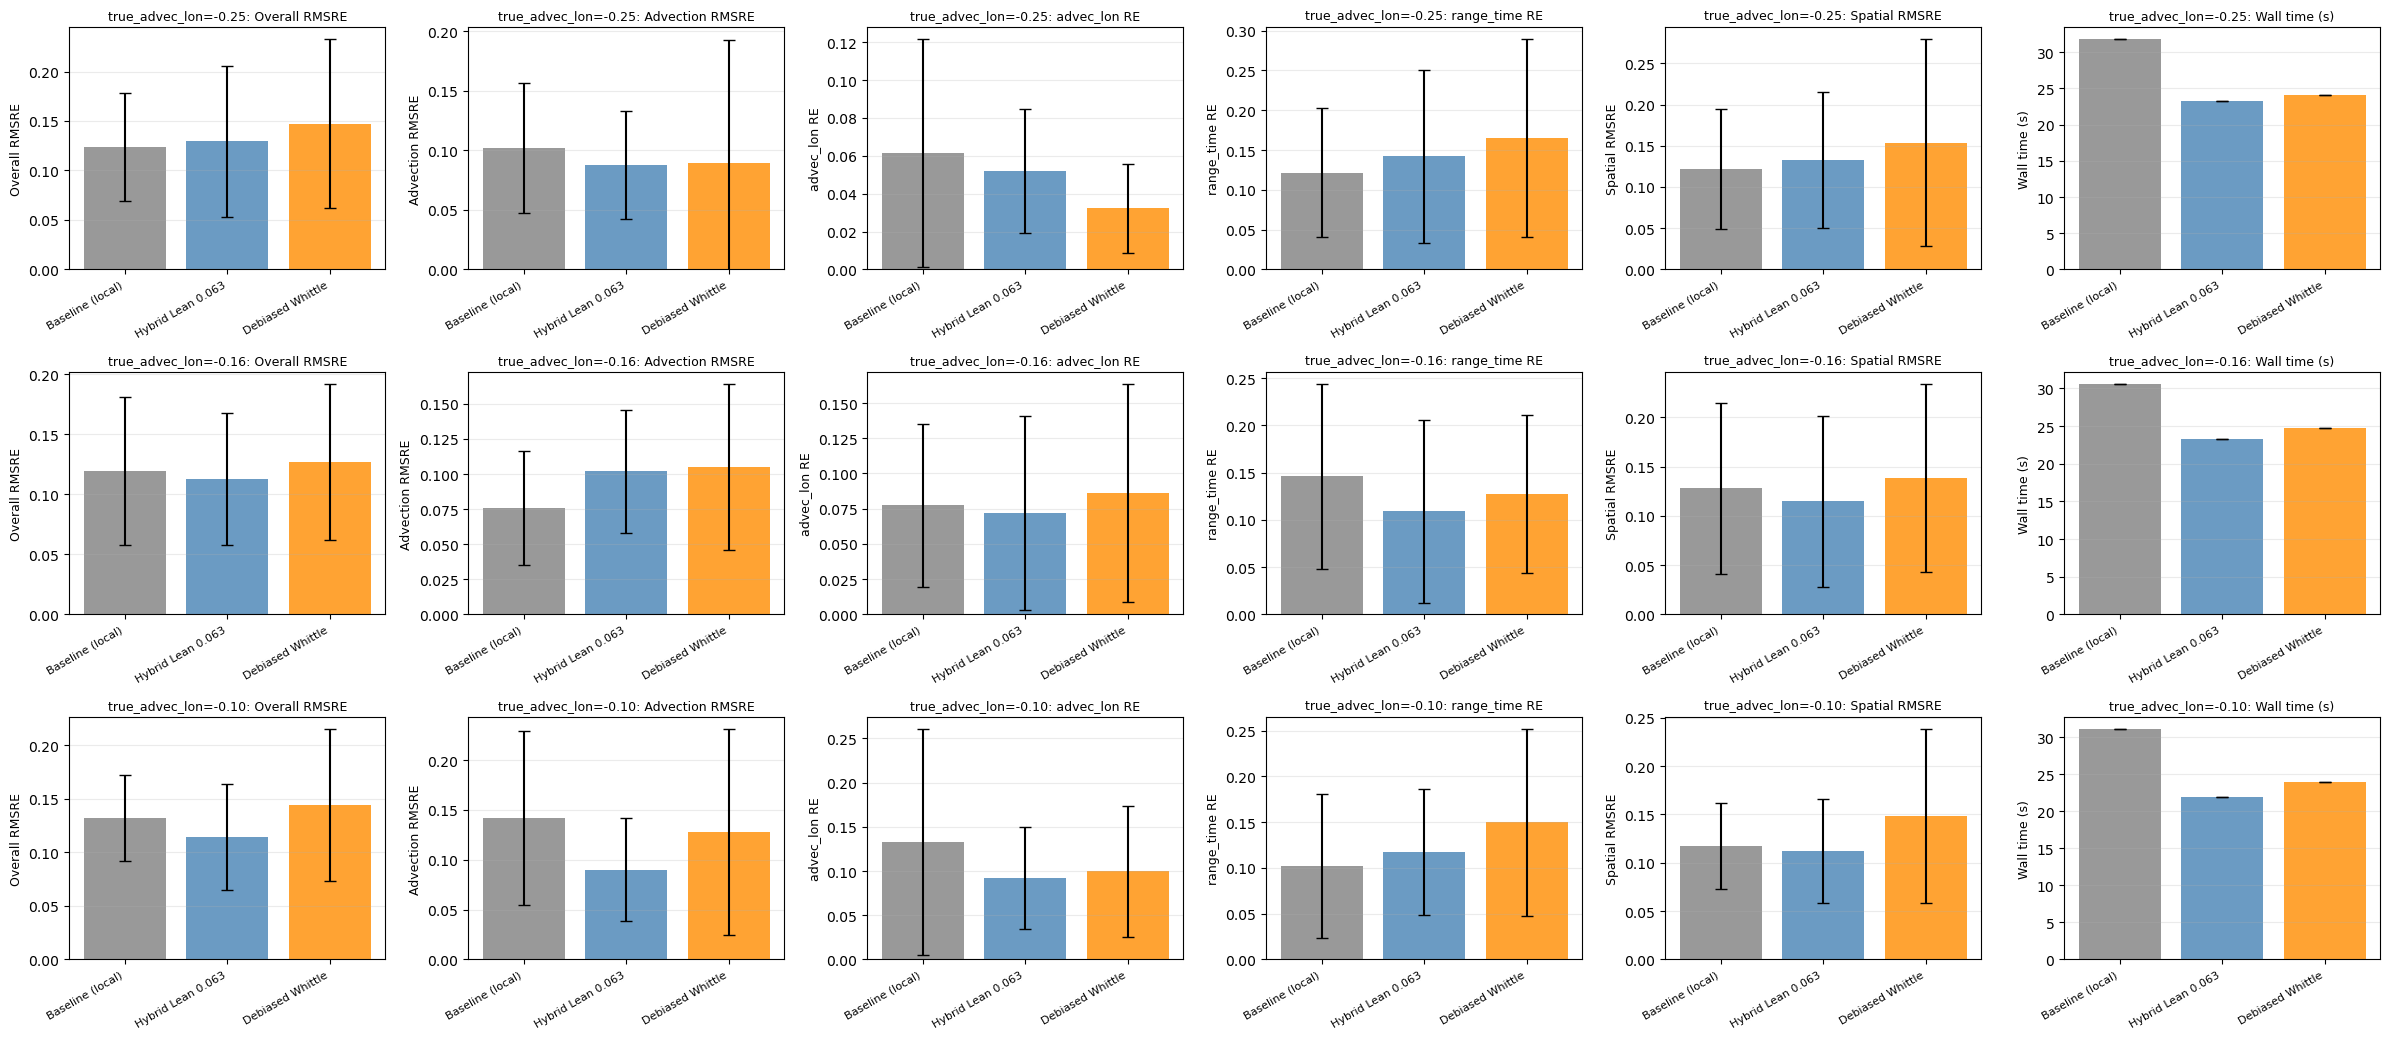

Saved: log/dw_compare_model_comparison.png


In [10]:
MODEL_ORDER  = ["Irr_Baseline_A20_B18_C15", "Hybrid_Lean_Fixed_0p063", "DW_2110"]
MODEL_COLORS = {
    "Irr_Baseline_A20_B18_C15": "gray",
    "Hybrid_Lean_Fixed_0p063":  "steelblue",
    "DW_2110":                  "darkorange",
}
MODEL_LABELS = {
    "Irr_Baseline_A20_B18_C15": "Baseline (local)",
    "Hybrid_Lean_Fixed_0p063":  "Hybrid Lean 0.063",
    "DW_2110":                  "Debiased Whittle",
}

metrics_to_plot = [
    ("overall_rmsre_mean",   "overall_rmsre_p90_p10",  "Overall RMSRE"),
    ("advec_rmsre_mean",     "advec_rmsre_p90_p10",    "Advection RMSRE"),
    ("advec_lon_re_mean",    "advec_lon_re_p90_p10",   "advec_lon RE"),
    ("range_time_re_mean",   "range_time_re_p90_p10",  "range_time RE"),
    ("spatial_rmsre_mean",   "spatial_rmsre_p90_p10",  "Spatial RMSRE"),
    ("total_s_mean",         None,                     "Wall time (s)"),
]

scenarios = sorted(mc_summary["true_advec_lon"].unique())
n_scen    = len(scenarios)
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(n_scen, n_metrics, figsize=(4 * n_metrics, 3.5 * n_scen), squeeze=False)

for row_i, ta in enumerate(scenarios):
    sub = mc_summary[mc_summary["true_advec_lon"] == ta]
    for col_j, (mean_col, spread_col, label) in enumerate(metrics_to_plot):
        ax = axes[row_i][col_j]
        for xi, mdl in enumerate(MODEL_ORDER):
            row_df = sub[sub["model"] == mdl]
            if row_df.empty or mean_col not in row_df.columns:
                continue
            val  = float(row_df[mean_col].iloc[0])
            yerr = (float(row_df[spread_col].iloc[0]) / 2.0
                    if spread_col and spread_col in row_df.columns else 0.0)
            ax.bar(xi, val, color=MODEL_COLORS.get(mdl, "steelblue"),
                   yerr=yerr, capsize=4, alpha=0.8,
                   label=MODEL_LABELS.get(mdl, mdl))
        ax.set_xticks(range(len(MODEL_ORDER)))
        ax.set_xticklabels([MODEL_LABELS.get(m, m) for m in MODEL_ORDER],
                           rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(f"true_advec_lon={ta:.2f}: {label}", fontsize=9)
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("log/dw_compare_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: log/dw_compare_model_comparison.png")

## Speed Table

In [11]:
time_summary = (
    mc_summary[["model", "kernel", "total_s_mean"]]
    .drop_duplicates(subset="model")
    .set_index("model")
)
ref_t = float(time_summary.loc["Irr_Baseline_A20_B18_C15", "total_s_mean"])
time_summary["slowdown_vs_baseline"] = time_summary["total_s_mean"] / ref_t
display(time_summary[["kernel", "total_s_mean", "slowdown_vs_baseline"]].round(3))

,kernel,total_s_mean,slowdown_vs_baseline
model,,,
Irr_Baseline_A20_B18_C15,std,31.128,1.000
Hybrid_Lean_Fixed_0p063,hybrid_fresh,21.976,0.706
DW_2110,dw,23.924,0.769


## Parameter Recovery Heatmap

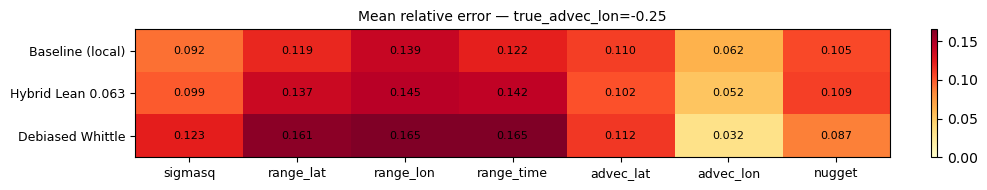

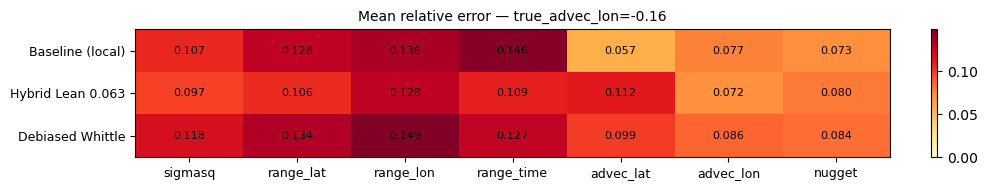

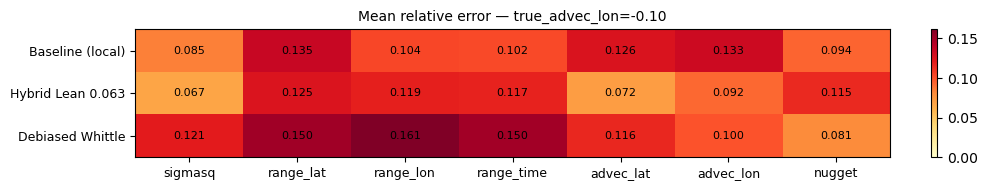

In [12]:
df_re = add_re_columns(df_mc.dropna(subset=["overall_rmsre"]))
par_cols = ["sigmasq_re", "range_lat_re", "range_lon_re",
            "range_time_re", "advec_lat_re", "advec_lon_re", "nugget_re"]
par_cols = [c for c in par_cols if c in df_re.columns]

agg = (
    df_re.groupby(["model", "true_advec_lon"])[par_cols]
    .mean()
    .reset_index()
)

for ta in sorted(agg["true_advec_lon"].unique()):
    sub = agg[agg["true_advec_lon"] == ta].set_index("model")[par_cols]
    sub = sub.reindex([m for m in MODEL_ORDER if m in sub.index])
    sub.columns = [c.replace("_re", "") for c in sub.columns]

    fig, ax = plt.subplots(figsize=(10, 2.0))
    im = ax.imshow(sub.values, aspect="auto", cmap="YlOrRd", vmin=0)
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, fontsize=9)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([MODEL_LABELS.get(m, m) for m in sub.index], fontsize=9)
    for i in range(len(sub)):
        for j in range(len(sub.columns)):
            ax.text(j, i, f"{sub.values[i, j]:.3f}", ha="center", va="center",
                    fontsize=8, color="black")
    plt.colorbar(im, ax=ax, fraction=0.02)
    ax.set_title(f"Mean relative error — true_advec_lon={ta:.2f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(f"log/dw_compare_re_heatmap_advec{int(abs(ta)*100):03d}.png",
                dpi=120, bbox_inches="tight")
    plt.show()

## Interpretation

**Key questions:**

1. **Does Debiased Whittle beat Hybrid Lean Vecchia overall?**  
   Check `overall_rmsre_mean`. DW is unbiased asymptotically but may have higher variance at small sample sizes.

2. **Where does DW struggle?**  
   DW applies first-difference filtering and works in frequency domain — check `advec_lon_re` and `range_time_re` specifically.

3. **Speed trade-off?**  
   DW uses FFT so it may be faster than Vecchia at this grid size, or comparable.

4. **Does advection magnitude matter?**  
   Compare performance across true_advec_lon = [-0.10, -0.16, -0.25].